In [23]:
import math
import numpy as np
from matplotlib import pyplot as plt
from pedestrian import *
from solver import Newmarkpseudo_HSI2, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *
from scipy.stats import norm

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = 0   
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 0 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])




alpha_COV= np.array([0.05,0.10,0.15,0.2])


alpha_std = mean_alpha*alpha_COV


t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


'''Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = 2 ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

'Human = Pedestrian(\n         mass = randomMass,     #kg\n         damp = peddamp ,   #%\n         stiff = kped, #N/m\n         pace  = 2 ,    #Hz\n         phase = randomPhase,\n         location = pedInlocation,\n         velocity = randomVelocity,\n         \n         iSync=0)'

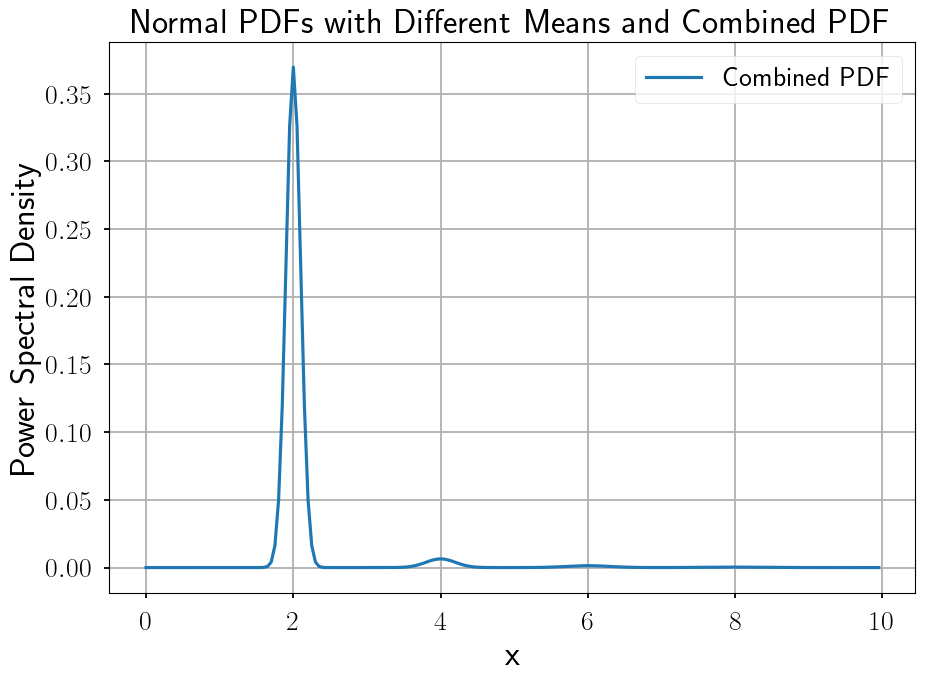

200
0.04999999999999999


In [24]:
from scipy.stats import norm


# Means and standard deviation
means = [2, 4, 6, 8] #the means of harmonics targetted
COV = 0.0335
mean_pace = 2    #maean step frequency
std_dev = mean_pace*alpha_COV #standard deviation of step frequency
mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])
# Generate x values
x = np.arange(0, 10, 0.05)

# Initialize a combined PDF array with zeros
combined_pdf = np.zeros(np.size(x))

# Plot each normal PDF
for i in range (np.size(means)):
    pdf = norm.pdf(x, means[i], std_dev[i])
    alpha = ((1*mean_alpha[i])**2)/2
    combined_pdf += pdf*alpha
   


frequencies = np.array(x)
psd = np.array(combined_pdf)
frequencies=frequencies[frequencies<(10)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]
# Plot the combined PDF
plt.plot(frequencies, psd, label='Combined PDF')

# Add title and labels
plt.title('Normal PDFs with Different Means and Combined PDF')
plt.xlabel('x')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(True)
# Show the plot
plt.show()

print(np.size(frequencies))
print(frequencies[4]-frequencies[3])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


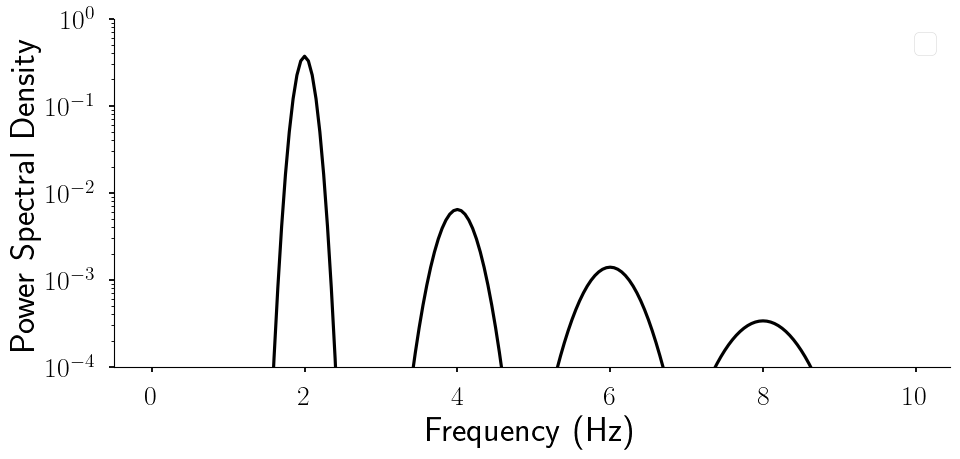

200
0.04999999999999999


In [31]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)

# Plot the combined PDF
plt.figure(figsize=(10,5))
plt.semilogy(frequencies, psd, color='black')

# Add title and labels
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(false)
# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Limit the y-axis to start from 10^-4
ax.set_ylim(bottom=1e-4)
ax.set_ylim(top=1)
# Add vertical lines at specific x-values
x_values = [2, 4, 6, 8]  # Example x-values where you want to add vertical lines
# Adjust layout to prevent cropping
plt.tight_layout()
plt.savefig("SIMSM_11 new.pdf", format='pdf', dpi=300)
plt.show()



print(np.size(frequencies))
print(frequencies[4]-frequencies[3])

0.4050999999999997


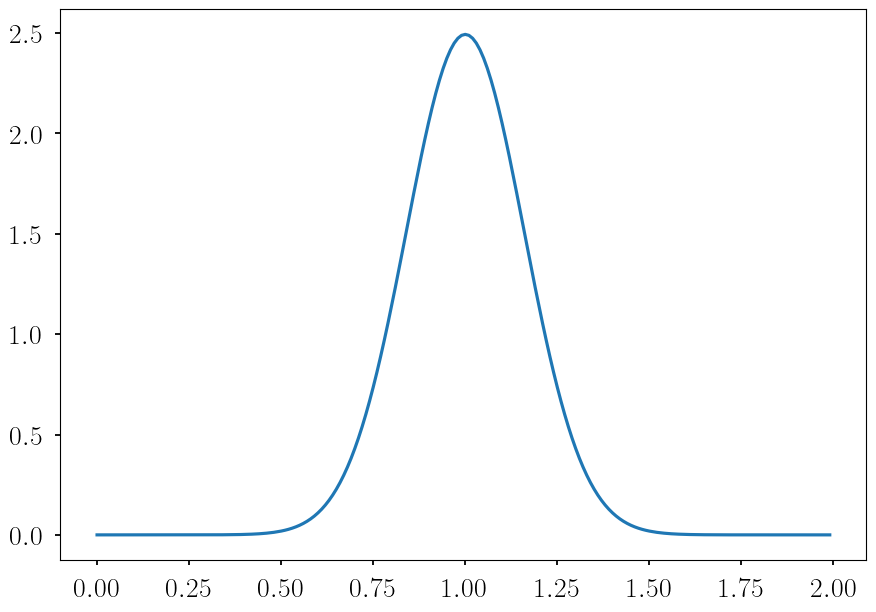

C:\Users\slok0019\AppData\Local\Temp\ipykernel_19296\2344069873.py:192: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(top=0)


<Figure size 1040x715 with 0 Axes>

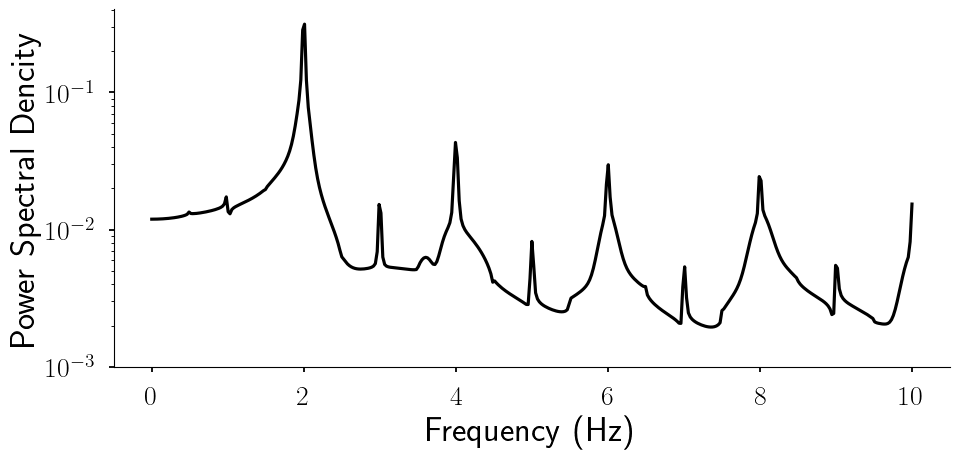

In [20]:
from matrix import*  
from solver import Newmarksuper_HSI2,accdyn_super,Newmarkpseudo_HSI2
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np
from scipy.stats import norm
from pseudo_excitation import*
from ZIV_SM import compute_subharmonic_dlf, compute_dlf

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

pace = mean_pace
mean_DLF1 = -0.2649*pace**3 +1.3206*pace**2-1.7597*pace+0.7613
print(mean_DLF1)

t = np.array(np.arange(0, (50+1) / 1.25, 0.01)) 

DLF2 = 0.07
DLF3 = 0.05
DLF4 = 0.05
DLF5 = 0.03 
DLF=np.array([mean_DLF1, DLF2, DLF3, DLF4, DLF5])

STD_DLF2 = 0.03
STD_DLF3 = 0.02
STD_DLF4 = 0.02
STD_DLF5 = 0.015


""" Data from the table for Harmonics Zivanovic and Pavic (2007)"""
i_values = [1, 2, 3, 4, 5]
a_i1_values = [0.785200, 0.513000, 0.390800, 0.325500, 0.280600]
b_i1_values = [0.999900, 2.000000, 3.000000, 4.000000, 4.999000]
c_i1_values = [0.008314, 0.011050, 0.009560, 0.008797, 0.007939]

a_i2_values = [0.020600, 0.133000, 0.156700, 0.164700, 0.158400]
b_i2_values = [1.034000, 1.957000, 3.000000, 4.001000, 5.004000]
c_i2_values = [0.252400, 0.263200, 0.055250, 0.066410, 0.078250]

a_i3_values = [0.107400, -0.049840, 0.068660, 0.068880, 0.072890]
b_i3_values = [1.001000, 1.882000, 2.957000, 3.991000, 4.987000]
c_i3_values = [0.036530, 0.058070, 0.560700, 0.375000, 0.450100]



""" Data from the table for Sub Harmonics Zivanovic and Pavic (2007)"""
a_s_i1_values = [0.340600, 0.302400, 0.262700, 0.234400, 0.264500]
b_s_i1_values = [0.498800, 1.500000, 2.500000, 3.501000, 4.499000]
c_s_i1_values = [0.008337, 0.008735, 0.009748, 0.009898, 0.010190]
a_s_i2_values = [0.280300, 0.134500, 0.245600, 0.235500, 0.238900]
b_s_i2_values = [1.133000, 1.532000, 0.231200, -1.576000, 1.153000]
c_s_i2_values = [0.638800, 0.723300, 2.932000, 7.050000, 4.561000]



x1 = np.arange(0, 2, 0.01) #multilpication factor transforming mean DLF into the distribution of DLF
pdf = norm.pdf(x1,1, 0.16)
#DLF1 = mean_DLF1*pdf
plt.plot(x1, pdf)
plt.show()

DLF_s_1= 0.026*mean_DLF1 + 0.0031
DLF_s_2= 0.074*mean_DLF1 + 0.01   
DLF_s_3= 0.012*mean_DLF1 + 0.016
DLF_s_4= 0.013*mean_DLF1 + 0.0093
DLF_s_5= 0.015*mean_DLF1 + 0.0072

DLF_s = np.array([DLF_s_1, DLF_s_2, DLF_s_3, DLF_s_4, DLF_s_5])

f_values = [pace, 2*pace, 3*pace, 4*pace, 5*pace]
i_values = [1,2,3,4,5]
dlf_values = []
x = np.linspace(0, 10, 1000)
sin = np.zeros(t.size)

for i in range(np.size(i_values)):
    f = f_values[i]
    f_range = np.arange(f - 0.5, f + 0.5,1/80)

    dlf_values = [compute_dlf(f_val, i,pace) for f_val in f_range]
    for k in range(np.size(f_range)):
        sin += dlf_values[k]*np.sin(2*np.pi*f_range[k]*t)*DLF[i]

    f_range2 = np.arange(f - 1.5, f - 0.5, 1/80)  # Adjust the step size as needed
    dlf_values2 = [compute_subharmonic_dlf(f_val, i,pace) for f_val in f_range2]

    for k in range(np.size(f_range2)):
        sin += dlf_values2[k]*np.sin(2*np.pi*f_range2[k]*t)*DLF_s[i]
# Compute the FFT
N = len(sin)
T = t[1] - t[0]  # Sampling interval
fft_values = np.fft.fft(sin)
fft_freq = np.fft.fftfreq(N, T)

# Get the single-sided spectrum
fft_values = fft_values[:N//2]
fft_freq = fft_freq[:N//2]
fft_magnitude = np.abs(fft_values) / N

# Filter frequencies less than 10 Hz
mask = fft_freq < 10
filtered_freq = fft_freq[mask]
filtered_magnitude = fft_magnitude[mask]

from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)
# Plot the single-sided FFT
plt.figure()
# Create a figure with a specific aspect ratio (width, height)
fig, ax = plt.subplots(figsize=(10, 5))  # Aspect ratio 2:
#plt.semilogy(frequencies, psd, color='red')
plt.semilogy(filtered_freq, filtered_magnitude*2, color='black')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Dencity")
ax.set_ylim(bottom=1e-3)
ax.set_ylim(top=0)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("ZIVSM PSD new", format='pdf', dpi=300)
plt.show()   

